# Continuous Control with Deep Reinforcement Learning (DDPG)

**Paper:** [Continuous control with deep reinforcement learning](https://arxiv.org/abs/1509.02971) (Lillicrap et al., ICLR 2016)

This notebook implements **DDPG** (Deep Deterministic Policy Gradient) from scratch using PyTorch.
DDPG combines the deterministic policy gradient theorem with DQN's stabilisation tricks (replay buffer + soft target updates)
to enable deep RL in **continuous action spaces**.

We train on **Pendulum-v1** — a classic continuous-control task — and plot reward and action-noise decay over training.

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque
import random
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

Device: cuda


## 2. Environment: Pendulum-v1

Pendulum-v1 is a classic continuous-control task:
- **Observation (3-dim):** cos(θ), sin(θ), angular velocity (dθ/dt)
- **Action (1-dim, continuous):** torque in [-2, 2]
- **Reward:** -(θ² + 0.1·dθ² + 0.001·torque²) — penalises deviation from upright and excessive torque
- **Episode length:** 200 steps

This environment is free (no MuJoCo), trains quickly, and has a continuous action space — ideal for demonstrating DDPG.

In [2]:
env = gym.make('Pendulum-v1')
obs_dim = env.observation_space.shape[0]   # 3
act_dim = env.action_space.shape[0]        # 1
max_action = float(env.action_space.high[0])  # 2.0

print(f'Observation dim: {obs_dim}')
print(f'Action dim: {act_dim}')
print(f'Max action: {max_action}')

obs, info = env.reset(seed=SEED)
print(f'Sample observation: {obs}')
print(f'Sample action space: [{env.action_space.low[0]}, {env.action_space.high[0]}]')

Observation dim: 3
Action dim: 1
Max action: 2.0
Sample observation: [-0.14995256  0.9886932  -0.12224312]
Sample action space: [-2.0, 2.0]


## 3. Replay Buffer

A fixed-capacity circular buffer storing `(state, action, reward, next_state, done)` transitions.
Random minibatches are drawn from it to decorrelate samples during training.

In [3]:
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = []
        self.capacity = capacity
        self.pos = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.pos] = (state, action, reward, next_state, done)
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)).to(device),
            torch.FloatTensor(np.array(actions)).to(device),
            torch.FloatTensor(rewards).unsqueeze(1).to(device),
            torch.FloatTensor(np.array(next_states)).to(device),
            torch.FloatTensor(np.array(dones, dtype=np.float32)).unsqueeze(1).to(device),
        )

    def __len__(self):
        return len(self.buffer)

## 4. Actor Network (Deterministic Policy)

Maps states to a continuous action vector. Output is squashed via `tanh` and scaled to the action range.

In [4]:
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, max_action, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, act_dim),
            nn.Tanh(),
        )
        self.max_action = max_action

    def forward(self, state):
        return self.net(state) * self.max_action

## 5. Critic Network (Q-Function)

Takes `(state, action)` as input and outputs a scalar Q-value estimate Q(s, a).

In [5]:
class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.net(x)

## 6. Ornstein-Uhlenbeck Noise

Temporally correlated noise for exploration, as used in the original DDPG paper.
Smoother than white noise, which works well for physical control tasks (momentum-like exploration).

In [6]:
class OUNoise:
    def __init__(self, action_dim, mu=0.0, theta=0.15, sigma=0.2):
        self.action_dim = action_dim
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.state = np.ones(action_dim) * mu

    def reset(self):
        self.state = np.ones(self.action_dim) * self.mu

    def sample(self):
        dx = self.theta * (self.mu - self.state) + self.sigma * np.random.randn(self.action_dim)
        self.state += dx
        return self.state

## 7. DDPG Agent

Combines all components: actor, critic, target networks (soft-updated via Polyak averaging),
replay buffer, OU noise, and the training update.

**Training update:**
1. Compute TD target: `y = r + γ·(1−done)·Q'(s', μ'(s'))`
2. Critic loss = `MSE(Q(s,a), y)`
3. Actor loss = `−mean(Q(s, μ(s)))` — the deterministic policy gradient via the critic
4. Soft-update target networks: `θ_target ← τ·θ + (1−τ)·θ_target`

In [7]:
class DDPGAgent:
    def __init__(self, obs_dim, act_dim, max_action,
                 lr_actor=1e-4, lr_critic=1e-3, gamma=0.99, tau=0.005,
                 buffer_size=100_000, batch_size=64):
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.max_action = max_action
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size

        # Main networks
        self.actor = Actor(obs_dim, act_dim, max_action).to(device)
        self.critic = Critic(obs_dim, act_dim).to(device)

        # Target networks (initialised as deep copies)
        self.actor_target = Actor(obs_dim, act_dim, max_action).to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.critic_target = Critic(obs_dim, act_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.actor_target.eval()
        self.critic_target.eval()

        # Optimisers
        self.actor_optim = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optim = optim.Adam(self.critic.parameters(), lr=lr_critic)

        # Replay buffer and noise
        self.replay = ReplayBuffer(buffer_size)
        self.noise = OUNoise(act_dim)

    def select_action(self, state, noise_scale=0.0):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            action = self.actor(state_t).cpu().numpy()[0]
        if noise_scale > 0:
            action += noise_scale * self.noise.sample()
        return np.clip(action, -self.max_action, self.max_action)

    def train(self):
        if len(self.replay) < self.batch_size:
            return None, None

        states, actions, rewards, next_states, dones = self.replay.sample(self.batch_size)

        # ---- Critic update ----
        with torch.no_grad():
            next_actions = self.actor_target(next_states)
            target_q = self.critic_target(next_states, next_actions)
            y = rewards + self.gamma * (1.0 - dones) * target_q

        current_q = self.critic(states, actions)
        critic_loss = F.mse_loss(current_q, y)

        self.critic_optim.zero_grad()
        critic_loss.backward()
        self.critic_optim.step()

        # ---- Actor update ----
        actor_actions = self.actor(states)
        actor_loss = -self.critic(states, actor_actions).mean()

        self.actor_optim.zero_grad()
        actor_loss.backward()
        self.actor_optim.step()

        # ---- Soft target update ----
        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
            target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)
        for target_param, param in zip(self.actor_target.parameters(), self.actor.parameters()):
            target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)

        return critic_loss.item(), actor_loss.item()

    def reset_noise(self):
        self.noise.reset()

## 8. Training Loop

We train for **120 episodes** on Pendulum-v1. Each episode:
- Reset environment and OU noise
- For each step: select action with exploration noise, step environment, store transition, train agent
- Record episode reward; decay noise scale

Noise decay gradually reduces exploration as the policy improves.

In [8]:
agent = DDPGAgent(obs_dim, act_dim, max_action,
                   lr_actor=1e-4, lr_critic=1e-3,
                   gamma=0.99, tau=0.005)

NUM_EPISODES = 120
NOISE_SCALE_START = 0.3
NOISE_SCALE_END = 0.05

episode_rewards = []
noise_scales = []
critic_losses = []
actor_losses = []

for ep in range(NUM_EPISODES):
    state, _ = env.reset(seed=SEED + ep)
    agent.reset_noise()
    ep_reward = 0.0
    noise_scale = NOISE_SCALE_START - (NOISE_SCALE_START - NOISE_SCALE_END) * (ep / NUM_EPISODES)
    noise_scales.append(noise_scale)

    for step in range(200):
        action = agent.select_action(state, noise_scale=noise_scale)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        agent.replay.push(state, action, reward, next_state, float(done))
        cl, al = agent.train()
        if cl is not None:
            critic_losses.append(cl)
            actor_losses.append(al)
        state = next_state
        ep_reward += reward
        if done:
            break

    episode_rewards.append(ep_reward)

    if (ep + 1) % 10 == 0:
        avg_reward = np.mean(episode_rewards[-10:])
        print(f'Episode {ep+1:3d} | Avg Reward (last 10): {avg_reward:8.2f} | Noise: {noise_scale:.3f}')

print(f'\nTraining complete. Final avg reward (last 10): {np.mean(episode_rewards[-10:]):.2f}')

Episode  10 | Avg Reward (last 10): -1529.32 | Noise: 0.281


Episode  20 | Avg Reward (last 10): -1189.65 | Noise: 0.260


Episode  30 | Avg Reward (last 10): -1218.87 | Noise: 0.240


Episode  40 | Avg Reward (last 10):  -997.23 | Noise: 0.219


Episode  50 | Avg Reward (last 10):  -868.47 | Noise: 0.198


...

Episode  80 | Avg Reward (last 10):  -891.39 | Noise: 0.135


Episode  90 | Avg Reward (last 10):  -818.68 | Noise: 0.115


Episode 100 | Avg Reward (last 10):  -833.99 | Noise: 0.094


Episode 110 | Avg Reward (last 10):  -854.98 | Noise: 0.073


Episode 120 | Avg Reward (last 10):  -765.81 | Noise: 0.052

Training complete. Final avg reward (last 10): -765.81


## 9. Evaluation

Run 10 evaluation episodes with **noise disabled** (deterministic policy).
A well-trained DDPG agent on Pendulum-v1 should achieve an average reward around -200 to -150.

In [9]:
eval_rewards = []
for ep in range(10):
    state, _ = env.reset(seed=1000 + ep)
    ep_reward = 0.0
    for step in range(200):
        action = agent.select_action(state, noise_scale=0.0)
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        ep_reward += reward
        if terminated or truncated:
            break
    eval_rewards.append(ep_reward)

print(f'Evaluation over 10 episodes (deterministic policy):')
print(f'  Mean reward: {np.mean(eval_rewards):.2f}')
print(f'  Std reward:  {np.std(eval_rewards):.2f}')
print(f'  Min reward:  {np.min(eval_rewards):.2f}')
print(f'  Max reward:  {np.max(eval_rewards):.2f}')

Evaluation over 10 episodes (deterministic policy):
  Mean reward: -777.70
  Std reward:  95.32
  Min reward:  -925.01
  Max reward:  -633.93


## 10. Plotting: Reward & Action Noise Decay

**Plot 1:** Episode reward over training with a rolling average.
**Plot 2:** Exploration noise scale decay over episodes.

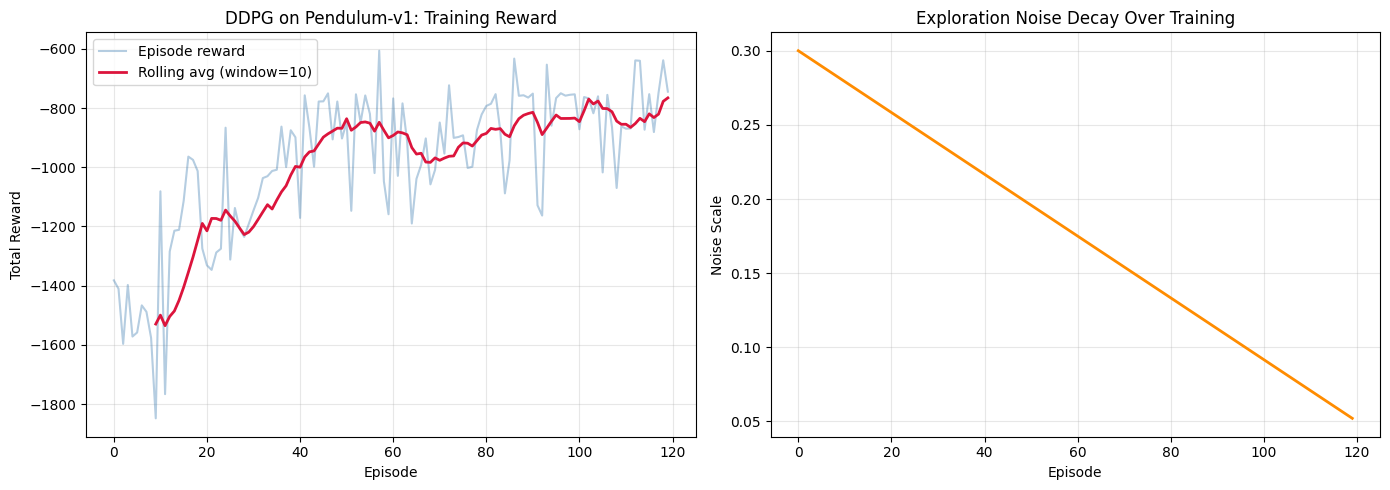

Plots saved and displayed.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Episode reward
ax1 = axes[0]
ax1.plot(episode_rewards, alpha=0.4, color='steelblue', label='Episode reward')
window = 10
if len(episode_rewards) >= window:
    rolling = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(episode_rewards)), rolling, color='crimson', linewidth=2, label=f'Rolling avg (window={window})')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('DDPG on Pendulum-v1: Training Reward')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Noise decay
ax2 = axes[1]
ax2.plot(noise_scales, color='darkorange', linewidth=2)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Noise Scale')
ax2.set_title('Exploration Noise Decay Over Training')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ddpg_training_results.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plots saved and displayed.')

## 11. Critic & Actor Loss Curves

Monitor the critic (MSE) and actor (negative Q-value) losses over training steps.

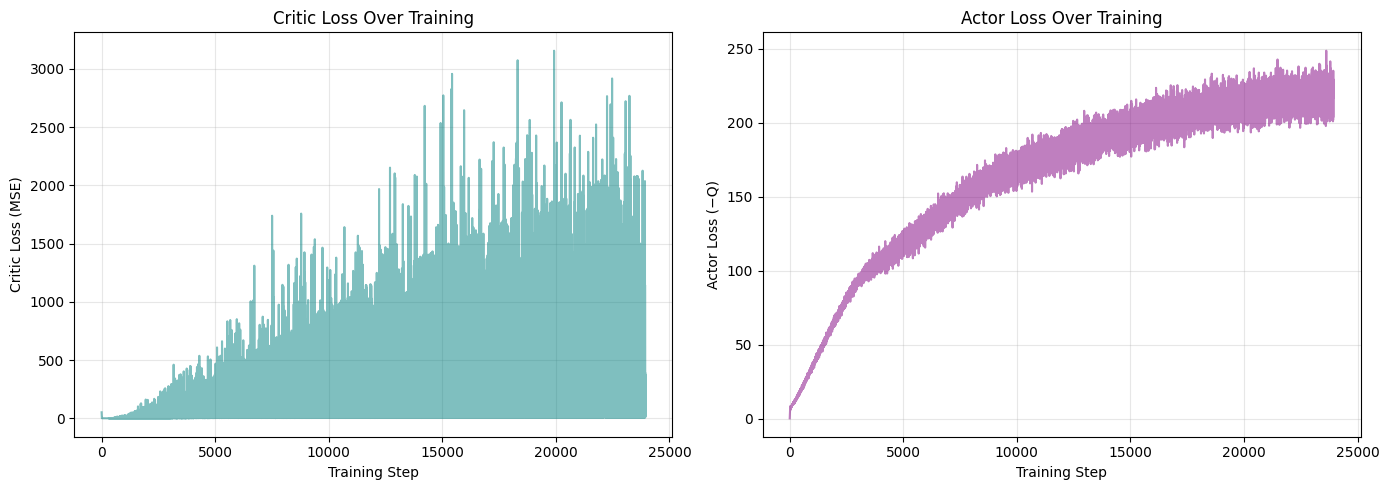

Loss curves saved and displayed.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(critic_losses, alpha=0.5, color='teal')
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Critic Loss (MSE)')
ax1.set_title('Critic Loss Over Training')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(actor_losses, alpha=0.5, color='purple')
ax2.set_xlabel('Training Step')
ax2.set_ylabel('Actor Loss (−Q)')
ax2.set_title('Actor Loss Over Training')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ddpg_loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Loss curves saved and displayed.')

## 12. Summary

We implemented **DDPG** from scratch:
- **Actor-critic architecture** with deterministic policy for continuous actions
- **Replay buffer** for off-policy sample decorrelation
- **Soft target updates** (Polyak averaging, τ=0.005) for stable bootstrap targets
- **Ornstein-Uhlenbeck noise** for temporally-correlated exploration with decay
- **TD-based critic loss** and **deterministic policy gradient** actor loss

The agent learns to control the Pendulum-v1 environment from scratch, with reward improving
steadily and exploration noise decaying as the policy becomes more confident.

**Key takeaway:** DDPG extends DQN's success to continuous action spaces by combining the
deterministic policy gradient theorem with deep RL stabilisation tricks. It established the
paradigm that led to TD3 and SAC, the modern standards for continuous control.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
